#KMeans

In [1]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
path = '/content/gdrive/MyDrive/SIS420/datasets/datasets_practicos/UCI_Credit_Card.csv'

df = pd.read_csv(path)

print("Dataset:\n", df.head())
print("Shape dataset:", df.shape)
print(df.info())

Dataset:
    ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0   

In [26]:
# Eliminar columnas que no aportan
X = df.drop(columns=['ID', 'default.payment.next.month'], errors='ignore')

# Guardar nombres (opcional)
feature_names_original = X.columns

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
cols = ['LIMIT_BAL', 'AGE', 'PAY_0']

# Obtener índices de esas columnas
indices = [X.columns.get_loc(c) for c in cols]

# Seleccionar esas columnas ya escaladas
X_3d = X_scaled[:, indices]

# Nombres reales para los ejes
feature_names = cols

## Funcion graficación

In [40]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_clusters(X, labels, title, feature_names=None):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, s=10)

    # Etiquetas de ejes
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_zlabel(feature_names[2])
    else:
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('X3')

    ax.set_title(title)


    ax.view_init(elev=20, azim=45)


    ax.set_box_aspect([1, 1, 1])

    plt.tight_layout()
    plt.show()

## K = 3


Clusters para k = 3
Centroides:
 [[ 1.1190658   0.08476763 -0.68600624]
 [-0.43371918  1.21071491  0.29087325]
 [-0.54453907 -0.74270724  0.31971213]]


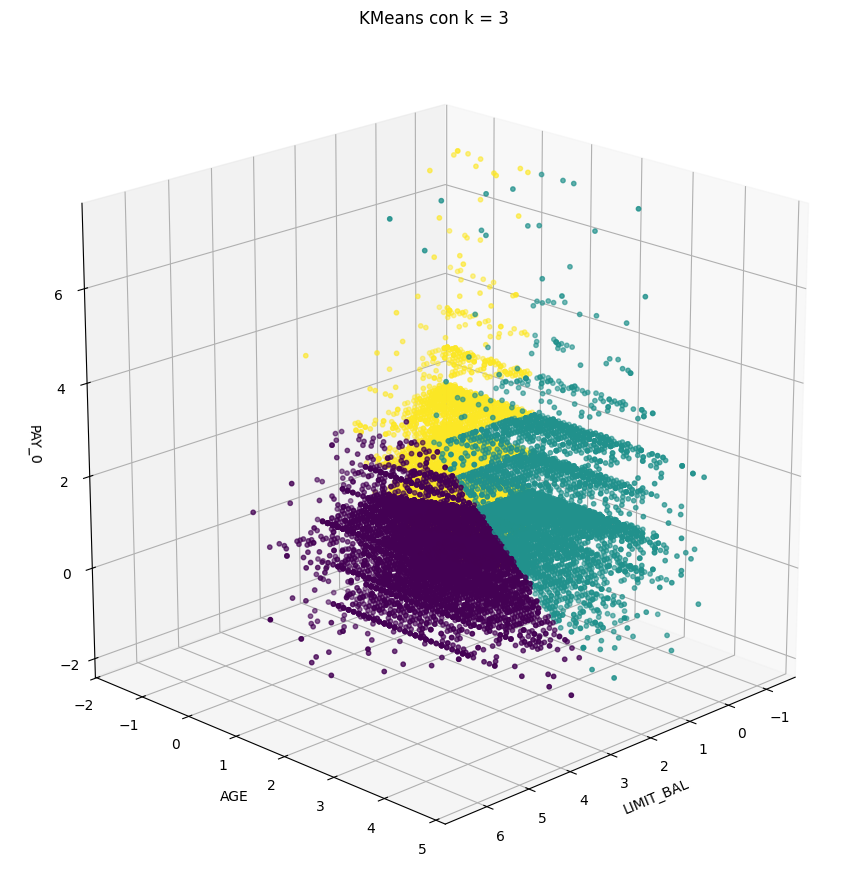

In [41]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k}")
print("Centroides:\n", kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred, f"KMeans con k = {k}", feature_names)

## K = 5


Clusters para k = 5
Centroides:
 [[ 1.8643375   0.52027696 -0.64403548]
 [ 0.57323493 -0.2823194   0.34423602]
 [-0.75968516 -0.77798901  0.57735642]
 [ 0.005246   -0.29288843 -1.1814498 ]
 [-0.52282473  1.31004815  0.26667594]]


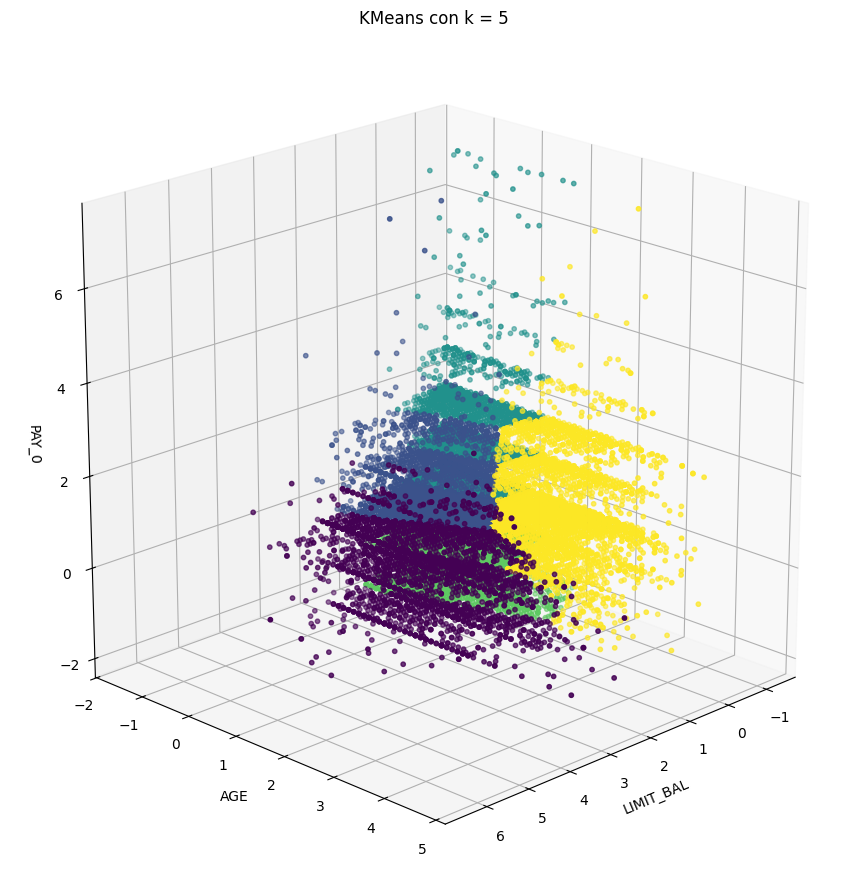

In [42]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k}")
print("Centroides:\n", kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred, f"KMeans con k = {k}", feature_names)

## K = 7


Clusters para k = 7
Centroides:
 [[ 0.89976506  1.53602099 -0.75718759]
 [ 0.46205922 -0.26215101  0.26121085]
 [-0.77231211 -0.86194629  0.05830465]
 [ 0.21124741 -0.26397972 -1.24030075]
 [-0.66805863  1.25667621  0.19681899]
 [ 2.0707489   0.03363471 -0.36920433]
 [-0.59381658 -0.25545814  1.94784859]]


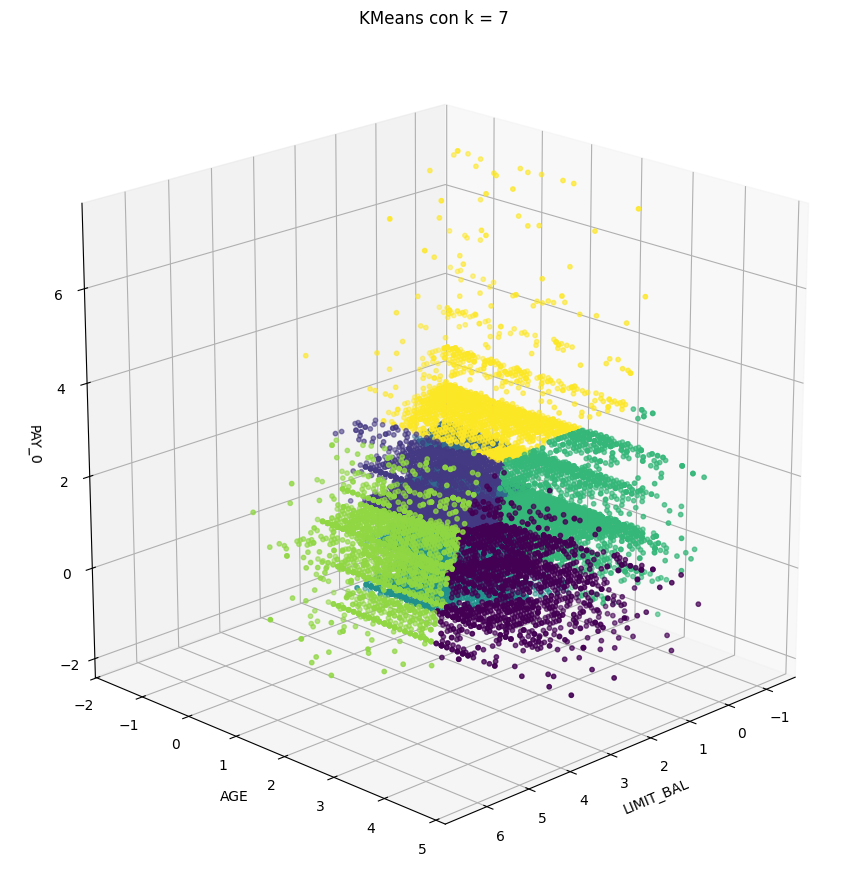

In [43]:
k = 7
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k}")
print("Centroides:\n", kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred, f"KMeans con k = {k}", feature_names)

## K = 9


Clusters para k = 9
Centroides:
 [[ 2.17958044  0.07541997 -0.44230407]
 [-0.60559286  0.42139929  0.02727995]
 [-0.70772782 -0.82494156  1.44459613]
 [-0.62203029  1.76877855  0.05424683]
 [ 0.68146062 -0.32498337  0.27825833]
 [-0.72094511 -0.96757873 -0.14151631]
 [ 0.31765315 -0.27876526 -1.27488672]
 [ 0.95609918  1.40567571 -0.79084346]
 [-0.44699752  0.95372933  2.13466424]]


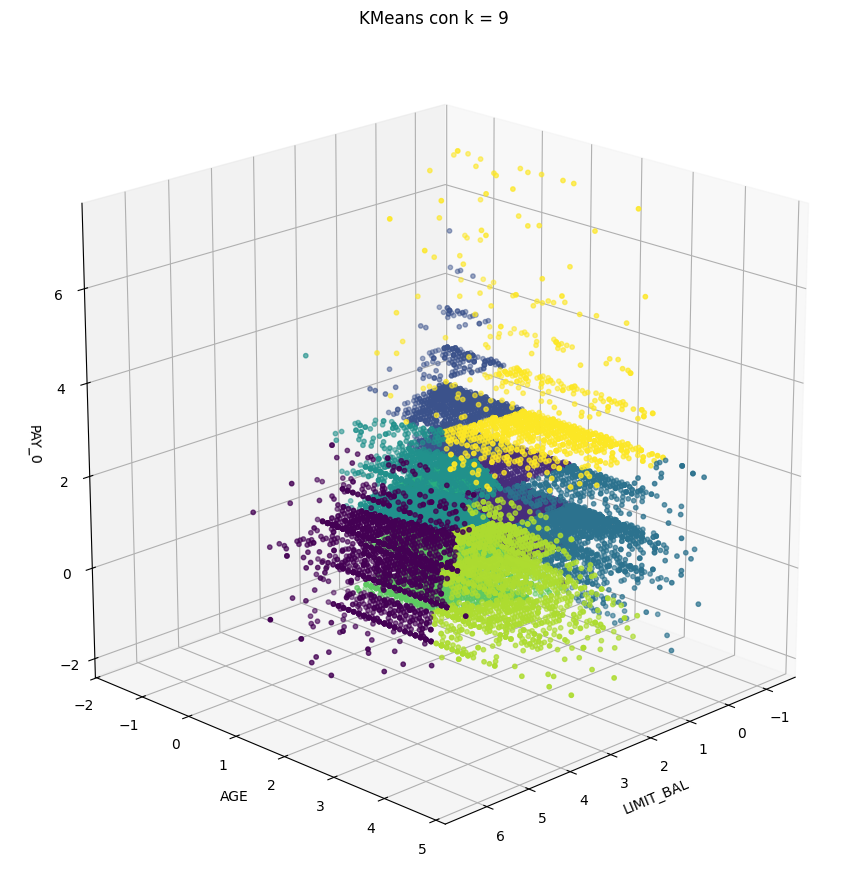

In [44]:
k = 9
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k}")
print("Centroides:\n", kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred, f"KMeans con k = {k}", feature_names)

## K = 3 con Minibatch




Clusters para k = 3 (MiniBatch)
Centroides:
 [[-0.39025444  1.24623034  0.45691123]
 [ 1.13974452  0.11009231 -0.66629717]
 [-0.56965269 -0.72098084  0.26084955]]


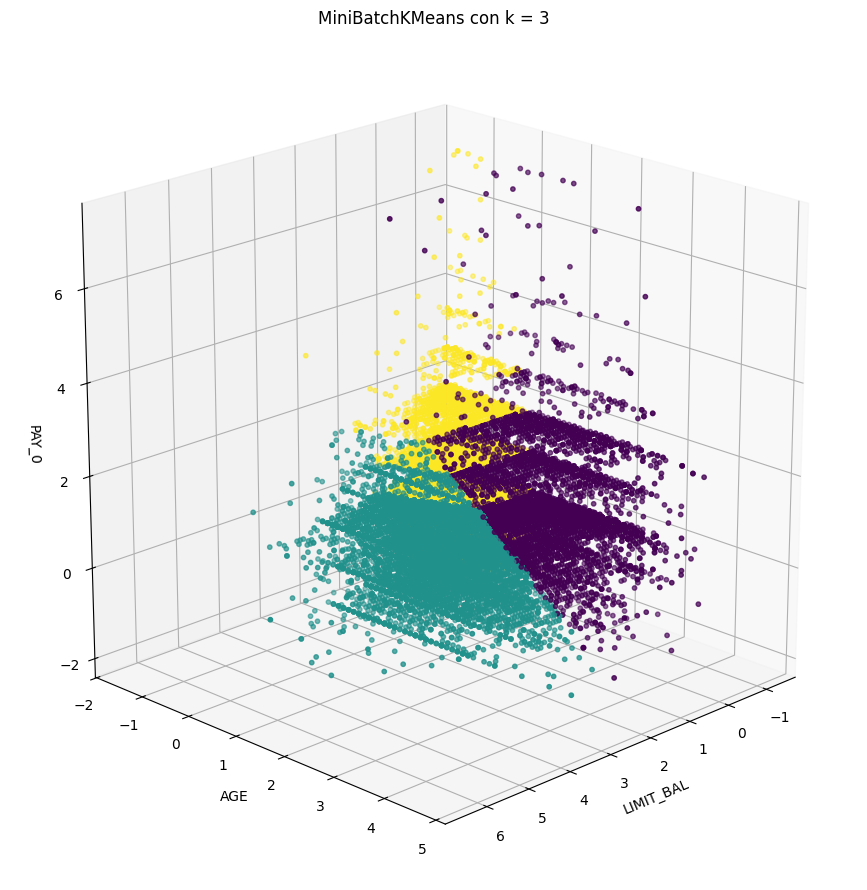

In [45]:
k = 3
mini_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42)

y_pred_mini = mini_kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k} (MiniBatch)")
print("Centroides:\n", mini_kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred_mini, f"MiniBatchKMeans con k = {k}", feature_names)

## K = 5 con Minibatch


Clusters para k = 5 (MiniBatch)
Centroides:
 [[-0.64390432  1.20182004  0.56117696]
 [ 0.88275843 -0.22041684  0.42115994]
 [-0.69439157 -0.7610855   0.20944119]
 [ 1.05999395 -0.29129825 -1.19447534]
 [ 0.72937682  1.17719816 -0.85425984]]


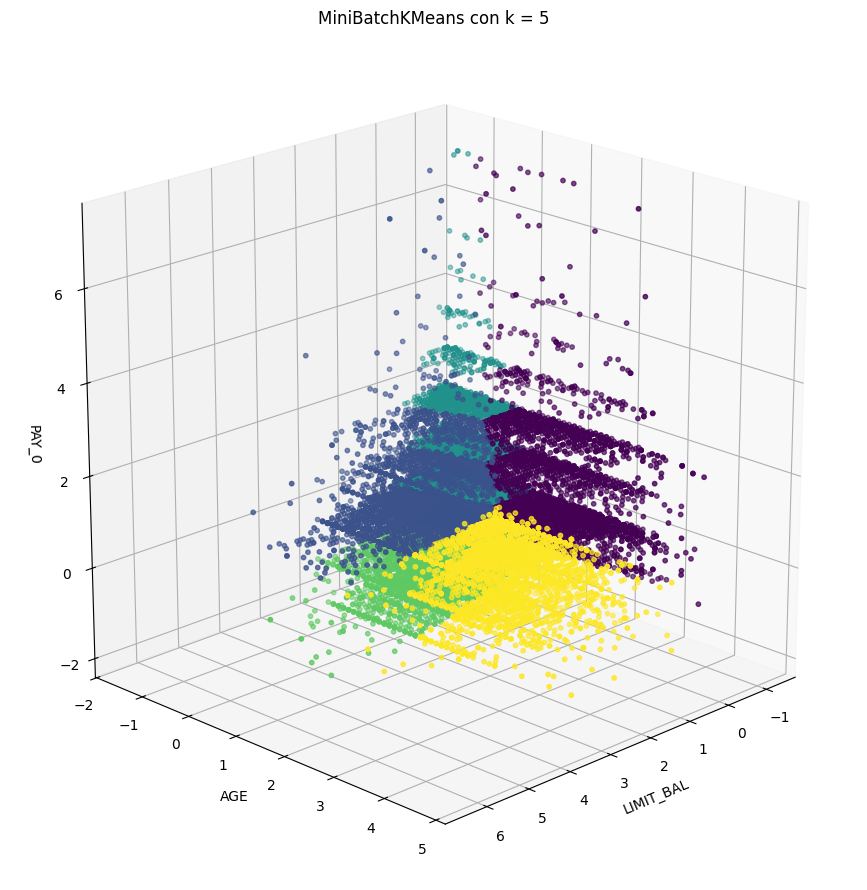

In [46]:
k = 5
mini_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42)

y_pred_mini = mini_kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k} (MiniBatch)")
print("Centroides:\n", mini_kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred_mini, f"MiniBatchKMeans con k = {k}", feature_names)

## K = 7 con Minibatch


Clusters para k = 7 (MiniBatch)
Centroides:
 [[-0.56822154  1.51305164  0.32450485]
 [ 1.0574054  -0.27929342  0.25233628]
 [-0.16306577  0.23728428 -0.70025664]
 [ 1.31107988 -0.26660396 -1.33861135]
 [ 1.7216651   1.26510963 -0.42864382]
 [-0.59812544 -0.27505629  1.88159526]
 [-0.69207677 -0.9107454   0.00709198]]


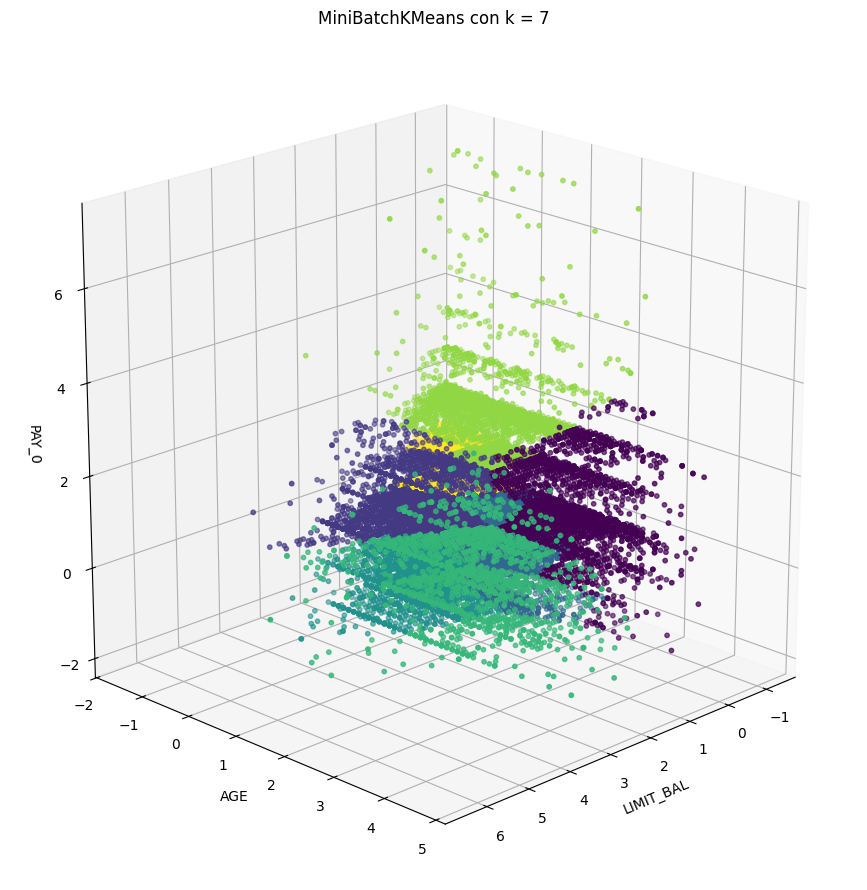

In [47]:
k = 7
mini_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42)

y_pred_mini = mini_kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k} (MiniBatch)")
print("Centroides:\n", mini_kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred_mini, f"MiniBatchKMeans con k = {k}", feature_names)

## K = 9 con Minibatch


Clusters para k = 9 (MiniBatch)
Centroides:
 [[-0.64891226  1.4364496   1.48518342]
 [-0.61122096 -0.8496366  -0.15413979]
 [ 1.55835092 -0.37229899  0.18457933]
 [-0.59510916 -0.64216796  1.52252704]
 [ 2.06048467  0.72539464 -0.9500208 ]
 [-0.77536612  1.07621672 -0.2559639 ]
 [ 0.47064005 -0.21133246 -1.34414736]
 [ 0.272538    0.38108932  0.02172313]
 [ 0.85005533  2.03346883 -0.17894792]]


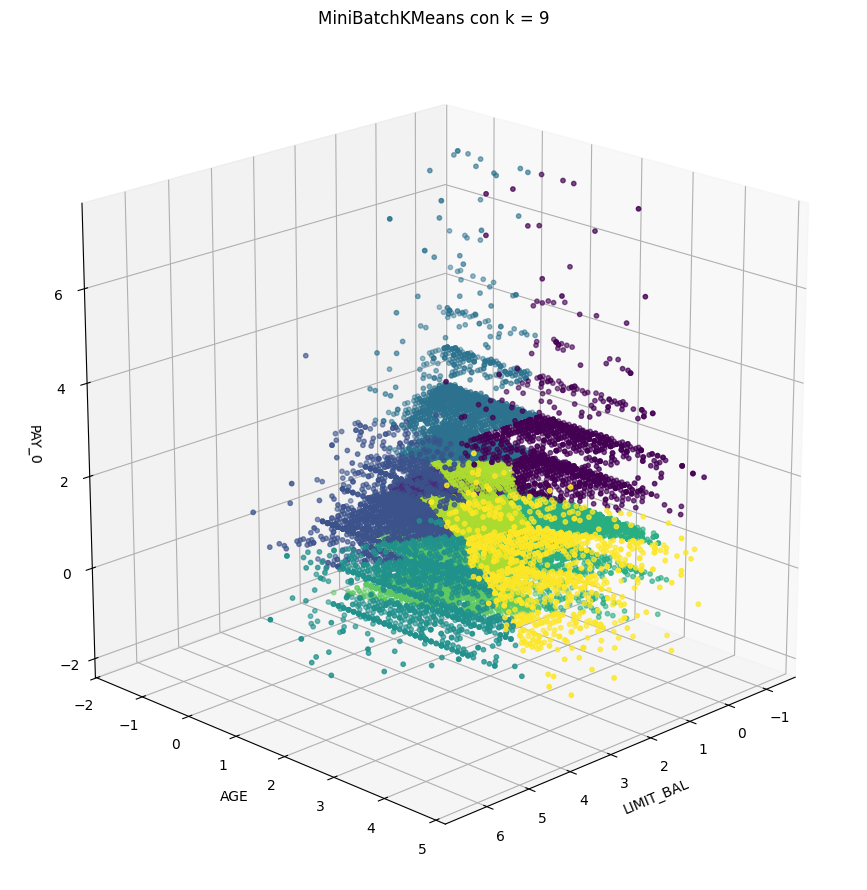

In [48]:
k = 9
mini_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42)

y_pred_mini = mini_kmeans.fit_predict(X_3d)

print(f"\nClusters para k = {k} (MiniBatch)")
print("Centroides:\n", mini_kmeans.cluster_centers_)

plot_3d_clusters(X_3d, y_pred_mini, f"MiniBatchKMeans con k = {k}", feature_names)